In [30]:
import sys
from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

if str(Path.cwd().parent) not in sys.path:
    sys.path.append(str(Path.cwd().parent))

from part1.ols_implementation import ols_fit, model_metrics, vif, coef_inference

## 3. Đánh giá mô hình (Model Metrics)

Sau khi tìm được các hệ số hồi quy $\hat{\beta}$, chúng ta cần đánh giá chất lượng của mô hình thông qua các chỉ số thống kê. Các chỉ số này giúp đo lường mức độ phù hợp của mô hình với dữ liệu thực tế.

**Các công thức tính toán:**
1. **Tổng bình phương sai lệch toàn phần (TSS):** Đo lường tổng biến động của dữ liệu thực tế.$TSS = \sum_{i=1}^{n} (y_i - \bar{y})^2$
2. **Tổng bình phương phần dư (RSS):** Đo lường tổng sai số của mô hình. $RSS = \sum_{i=1}^{n} (y_i - \hat{y}_i)^2$
3. **Hệ số xác định ($R^2$):** Tỷ lệ phương sai của biến phụ thuộc được giải thích bởi mô hình. $R^2 = 1 - \frac{RSS}{TSS}$ 
4. **$R^2$ hiệu chỉnh (Adjusted $R^2$):** Phiên bản điều chỉnh của $R^2$ nhằm phạt mô hình nếu thêm vào quá nhiều biến độc lập không cần thiết. $Adj\_R^2 = 1 - \frac{(1 - R^2)(n - 1)}{n - p - 1}$
5. **Sai số tuyệt đối trung bình (MAE):** Trung bình của các giá trị tuyệt đối của sai số. $MAE = \frac{1}{n} \sum_{i=1}^{n} |y_i - \hat{y}_i|$
6. **Sai số toàn phương trung bình (RMSE):** Căn bậc hai của trung bình bình phương sai số. $RMSE = \sqrt{\frac{RSS}{n}}$
7. **Tiêu chuẩn F (F-statistic):** Kiểm định giả thuyết cho rằng tất cả các hệ số hồi quy (trừ intercept) đều bằng 0. $F_{stat} = \frac{(TSS - RSS) / p}{RSS / (n - p - 1)}$

In [31]:
# 1. Khởi tạo dữ liệu mẫu với ma trận đặc trưng gốc X_demo (KHÔNG tự chèn intercept)
np.random.seed(42)
n_samples = 100
p_features = 3  # Số lượng biến độc lập gốc
X_demo = np.random.randn(n_samples, p_features)

# Định nghĩa beta thực tế bao gồm cả intercept ở vị trí đầu tiên để sinh dữ liệu y
beta_true = np.array([2.5, 1.5, -0.8, 0.5])
X_aug_true = np.column_stack([np.ones(n_samples), X_demo])
y_demo = X_aug_true @ beta_true + np.random.normal(0, 0.1, n_samples)

# 2. Chạy hồi quy OLS (Hàm ols_fit sẽ tự động biến đổi và thêm cột intercept vào X)
beta_hat, sigma2 = ols_fit(X_demo, y_demo)

# 3. Dự đoán y_hat sử dụng ma trận đã chèn cột intercept để tương thích với beta_hat
X_demo_with_intercept = np.column_stack([np.ones(n_samples), X_demo])
y_hat_demo = X_demo_with_intercept @ beta_hat

# 4. Chạy hàm đánh giá mô hình
metrics_result = model_metrics(y_demo, y_hat_demo, p_features)

# 5. In kết quả trực quan ra màn hình
print("--- KẾT QUẢ ĐÁNH GIÁ MÔ HÌNH (MODEL METRICS) ---")
keys_to_print = ["RSS", "TSS", "R2", "Adjusted_R2", "F_statistic", "MAE", "RMSE"]
for key in keys_to_print:
    value = metrics_result[key]
    print(f"{key}: {value:.4f}")

--- KẾT QUẢ ĐÁNH GIÁ MÔ HÌNH (MODEL METRICS) ---
RSS: 0.7568
TSS: 245.4184
R2: 0.9969
Adjusted_R2: 0.9968
F_statistic: 10345.6018
MAE: 0.0697
RMSE: 0.0870


## 4. Kiểm tra đa cộng tuyến (Variance Inflation Factor - VIF)

Đa cộng tuyến xảy ra khi các biến độc lập trong mô hình có sự tương quan tuyến tính mạnh với nhau. Điều này làm cho các ước lượng hệ số hồi quy trở nên kém tin cậy, sai số chuẩn bị phóng đại (tăng cao) và khó xác định chính xác tác động riêng biệt của từng biến giải thích lên biến phụ thuộc.

**Các bước tính toán VIF:**
1. **Hồi quy phụ (Auxiliary Regression):** Ứng với mỗi biến độc lập $X_j$, tiến hành xây dựng một mô hình hồi quy tuyến tính trong đó $X_j$ đóng vai trò là biến phụ thuộc, và tất cả các biến độc lập còn lại đóng vai trò là biến giải thích.
2. **Tính $R_j^2$:** Trích xuất hệ số xác định $R^2$ từ mô hình hồi quy phụ vừa thiết lập của biến $X_j$.
3. **Tính hệ số nhân phương sai (VIF):** Tính toán chỉ số VIF cho biến $X_j$ theo công thức nghịch đảo:
   $$VIF_j = \frac{1}{1 - R_j^2}$$

**Tiêu chí đánh giá hệ số:**
* **$VIF = 1$:** Các biến độc lập hoàn toàn không có hiện tượng đa cộng tuyến (trực giao).
* **$1 < VIF < 5$:** Có đa cộng tuyến nhưng ở mức độ nhẹ, hoàn toàn chấp nhận được.
* **$VIF > 10$:** Xuất hiện hiện tượng đa cộng tuyến nghiêm trọng, các hệ số hồi quy không còn đáng tin cậy. Cần xem xét loại bỏ biến hoặc áp dụng các phương pháp xử lý chuyên sâu.

In [32]:
# 1. Khởi tạo dữ liệu mẫu có tính đa cộng tuyến cao (x3 phụ thuộc tuyến tính vào x1 và x2)
np.random.seed(42)
x1 = np.random.randn(100)
x2 = np.random.randn(100)
# Thêm một lượng nhiễu cực nhỏ để tạo sự tương quan gần như hoàn hảo
x3 = x1 + x2 + np.random.normal(0, 0.01, 100)
X_multicollinear = np.column_stack([x1, x2, x3])

# 2. Chạy hàm kiểm tra đa cộng tuyến (VIF) trên ma trận dữ liệu mẫu
vif_values = vif(X_multicollinear)

# 3. In kết quả mẫu trực quan ra màn hình Notebook
print("--- KẾT QUẢ KIỂM TRA ĐA CỘNG TUYẾN (VIF) ---")
for i, v in enumerate(vif_values):
    print(f"VIF của biến độc lập X{i+1}: {v:.4f}")

--- KẾT QUẢ KIỂM TRA ĐA CỘNG TUYẾN (VIF) ---
VIF của biến độc lập X1: 7359.4031
VIF của biến độc lập X2: 7977.6630
VIF của biến độc lập X3: 13218.8218


## 5. Suy diễn thống kê cho các hệ số (Statistical Inference)

Để xác định xem một biến độc lập có thực sự ảnh hưởng đến biến phụ thuộc hay không, chúng ta thực hiện kiểm định giả thuyết thống kê cho từng hệ số $\beta_j$.

**Các bước tính toán và công thức:**
1. **Ma trận hiệp phương sai (Covariance Matrix):** Tính toán biến động của ước lượng hệ số. $Var(\hat{\beta}_{OLS} | X) = \sigma^2 (X^T X)^+$ *(Sử dụng giả nghịch đảo Moore-Penrose để xử lý trường hợp ma trận gần suy biến hoặc đa cộng tuyến)*.
2. **Sai số chuẩn (Standard Error - SE):** Lấy căn bậc hai các phần tử trên đường chéo chính của ma trận hiệp phương sai.
   $$SE(\hat{\beta}_j) = \sqrt{[Var(\hat{\beta}_{OLS} | X)]_{jj}}$$
3. **Giá trị $t$-statistic:** Thực hiện kiểm định giả thuyết $H_0: \beta_j = 0$ (biến không có ý nghĩa).
   $$t_j = \frac{\hat{\beta}_j}{SE(\hat{\beta}_j)}$$
4. **Giá trị $p$-value:** Tra bảng phân phối Student-$t$ với bậc tự do là $n - p - 1$. Nếu $p$-value < 0.05, chúng ta bác bỏ giả thuyết $H_0$, đồng nghĩa với việc hệ số đó có ý nghĩa thống kê ở mức độ tin cậy 95%.
5. **Khoảng tin cậy 95% (Confidence Interval - CI):** Ước lượng vùng chứa giá trị thực của hệ số $\beta_j$ với độ tin cậy 95%:
   $$CI = \left[ \hat{\beta}_j - t_{\alpha/2, n-p-1} \times SE(\hat{\beta}_j), \;\; \hat{\beta}_j + t_{\alpha/2, n-p-1} \times SE(\hat{\beta}_j) \right]$$

In [33]:
# 1. Khởi tạo dữ liệu mẫu kiểm định mới (X_inference gồm các predictors gốc)
np.random.seed(42)
n_samples = 100
X_inference = np.random.randn(n_samples, 3)

# Thiết lập hệ số thực: Gồm 4 phần tử tương ứng (Intercept, Beta1, Beta2, Beta3)
beta_true_inf = np.array([10.0, 5.0, 0.01, -2.3])
X_aug_inf = np.column_stack([np.ones(n_samples), X_inference])
epsilon = np.random.normal(0, 0.5, n_samples)
y_inference = X_aug_inf @ beta_true_inf + epsilon

# 2. Chạy hồi quy OLS để lấy ước lượng hệ số beta_hat và phương sai sai số sigma2
beta_hat, sigma2 = ols_fit(X_inference, y_inference)

# 3. Chuẩn bị ma trận X đã bao gồm cột Intercept trước khi truyền vào coef_inference
X_inference_with_intercept = np.column_stack([np.ones(n_samples), X_inference])

# 4. Chạy hàm suy diễn thống kê
inference_results = coef_inference(
    X_inference_with_intercept, y_inference, beta_hat, sigma2
)

# 5. In kết quả trực quan ra màn hình Notebook
print("--- KẾT QUẢ SUY DIỄN THỐNG KÊ (COEF INFERENCE) ---")
labels = [
    "Intercept (Beta0)",
    "Predictor 1 (Beta1)",
    "Predictor 2 (Beta2)",
    "Predictor 3 (Beta3)",
]
for i, label in enumerate(labels):
    print(f"\n[{label}]:")
    print(f"  Hệ số ước lượng (Beta_hat): {beta_hat[i]:.4f}")
    print(
        f"  Sai số chuẩn (SE):          {inference_results['standard_errors'][i]:.4f}"
    )
    print(f"  Giá trị t-statistic:        {inference_results['t_statistics'][i]:.4f}")
    print(f"  Giá trị p-value:            {inference_results['p_values'][i]:.4e}")
    print(
        f"  Khoảng tin cậy 95% (CI):    [{inference_results['ci_lower'][i]:.4f}, {inference_results['ci_upper'][i]:.4f}]"
    )

--- KẾT QUẢ SUY DIỄN THỐNG KÊ (COEF INFERENCE) ---

[Intercept (Beta0)]:
  Hệ số ước lượng (Beta_hat): 10.0564
  Sai số chuẩn (SE):          0.0455
  Giá trị t-statistic:        221.1424
  Giá trị p-value:            8.5058e-132
  Khoảng tin cậy 95% (CI):    [9.9662, 10.1467]

[Predictor 1 (Beta1)]:
  Hệ số ước lượng (Beta_hat): 4.9612
  Sai số chuẩn (SE):          0.0546
  Giá trị t-statistic:        90.8535
  Giá trị p-value:            6.5963e-95
  Khoảng tin cậy 95% (CI):    [4.8528, 5.0696]

[Predictor 2 (Beta2)]:
  Hệ số ước lượng (Beta_hat): -0.0150
  Sai số chuẩn (SE):          0.0460
  Giá trị t-statistic:        -0.3256
  Giá trị p-value:            7.4546e-01
  Khoảng tin cậy 95% (CI):    [-0.1063, 0.0764]

[Predictor 3 (Beta3)]:
  Hệ số ước lượng (Beta_hat): -2.3538
  Sai số chuẩn (SE):          0.0407
  Giá trị t-statistic:        -57.7831
  Giá trị p-value:            2.1924e-76
  Khoảng tin cậy 95% (CI):    [-2.4347, -2.2729]


## Mô Phỏng Monte Carlo Kiểm Chứng Định Lý Gauss-Markov

### 1. Giới Thiệu Khái Quát & Mục Tiêu

Định lý **Gauss-Markov** là một trong những cột trụ lý thuyết quan trọng nhất của phân tích hồi quy tuyến tính cổ điển. Định lý phát biểu rằng: Trong các ước lượng tuyến tính và không chệch của hệ số hồi quy $\beta$, ước lượng **Bình phương nhỏ nhất (OLS)** là ước lượng có **phương sai nhỏ nhất** (đạt hiệu quả cao nhất). Hay nói cách khác, OLS là **BLUE** (*Best Linear Unbiased Estimator*).

Mục tiêu của chương này là xây dựng một chương trình mô phỏng thực nghiệm **Monte Carlo** với số lượt lặp lớn ($B = 1000$) nhằm:
1. Chứng minh tính không chệch của OLS: $\mathbb{E}[\hat{\beta}_{OLS}] = \beta$.
2. Chứng minh tính tối ưu về phương sai: $\text{Var}(\hat{\beta}_{OLS}) < \text{Var}(\hat{\beta}_{other})$ với $\hat{\beta}_{other}$ là một ước lượng tuyến tính không chệch bất kỳ khác.

---

### 2. Các Giả Thiết Thỏa Mãn (Gauss-Markov Assumptions)

Để định lý Gauss-Markov được thiết lập vững chắc, dữ liệu mô phỏng được sinh ra phải tuân thủ nghiêm ngặt các giả thiết từ **GM1** đến **GM5**:

| Ký hiệu | Tên giả thiết | Biểu thức toán học / Mô tả | Ý nghĩa trong mô phỏng |
| :--- | :--- | :--- | :--- |
| **GM1** | Tuyến tính trong tham số | $y = X\beta + \epsilon$ | Dữ liệu được tổng hợp theo quan hệ tuyến tính giữa các thuộc tính và nhiễu. |
| **GM2** | Không hoàn hảo đa cộng tuyến | $\text{rank}(X) = p + 1$ | Ma trận thiết kế $X$ đạt hạng đầy đủ. Các biến độc lập không phụ thuộc tuyến tính vào nhau. |
| **GM3** | Kỳ vọng nhiễu bằng 0 | $\mathbb{E}[\epsilon \vert X] = 0$ | Sai số ngẫu nhiên không mang thông tin hệ thống, có trung bình xấp xỉ bằng 0. |
| **GM4** | Phương sai nhiễu thuần nhất | $\text{Var}(\epsilon \vert X) = \sigma^2 I_n$ | Độ phân tán của sai số là hằng số $\sigma^2$ đối với mọi quan sát (Homoscedasticity). |
| **GM5** | Không tự tương quan sai số | $\text{Cov}(\epsilon_i, \epsilon_j \vert X) = 0, \forall i \neq j$ | Sai số của các quan sát độc lập hoàn toàn với nhau. |

---

### 3. Thiết Kế Kịch Bản Mô Phỏng Monte Carlo

Quy trình thực nghiệm kiểm chứng được triển khai qua các bước sau:

```mermaid
graph TD
    %% Định nghĩa phong cách (Styling)
    classDef startEnd fill:#f9f,stroke:#333,stroke-width:2px,rx:10px;
    classDef process fill:#bbf,stroke:#333,stroke-width:1px;
    classDef loop fill:#ffd,stroke:#333,stroke-width:1px;

    %% Các nút trong sơ đồ
    Start([1. Cố định Ma trận X & Hệ số Beta_true]) --> LoopStart

    subgraph Monte_Carlo_Loop [Vòng lặp Monte Carlo B = 1000 lượt]
        LoopStart[2. Sinh nhiễu ngẫu nhiên epsilon<br>thỏa mãn giả thiết Gauss-Markov] --> Step3
        Step3[3. Tính toán Vector mục tiêu:<br>y = X * Beta_true + epsilon] --> Step4
        Step4[4. Áp dụng các toán tử ước lượng:<br>- Ước lượng OLS W_ols * y<br>- Ước lượng đối chứng W_other * y]
    end

    Step4 -->|Lặp lại B lần| LoopStart
    Step4 --> End[5. Thống kê Kỳ vọng & Phương sai<br>6. Trực quan hóa phân phối bằng KDE]

    %% Áp dụng phong cách
    class Start,End startEnd;
    class Step3,Step4 process;
    class LoopStart loop;
```

**Bộ ước lượng đối chứng ($W_{other}$):** Để làm nổi bật tính "Tốt nhất" (Best - phương sai nhỏ nhất) của OLS[cite: 2], chúng ta thiết lập một ước lượng tuyến tính không chệch khác bằng thuật toán Bình phương tối thiểu có trọng số (WLS) với các trọng số dở tệ ngẫu nhiên:
  $$W_{other} = (X^T W X)^{-1} X^T W$$
  Dù có trọng số không tối ưu, toán tử này về mặt lý thuyết vẫn đảm bảo tính không chệch ($\mathbb{E}[\hat{\beta}_{other}] = \beta$) nhưng sẽ có phương sai lớn hơn OLS.

---

## 4. Kiểm Định Thực Nghiệm (Unit Tests)
Trước khi tiến hành chạy mô phỏng diện rộng, hàm sinh dữ liệu cốt lõi `generate_synthetic_data` cần vượt qua 2 bài kiểm tra thực nghiệm nghiêm ngặt trong file `part1/test_gauss_markov.py` để đảm bảo không vi phạm giả thiết lý thuyết:
* **Test Case 1 (Kiểm chứng GM2):** Sử dụng `np.linalg.matrix_rank` để xác thực ma trận thiết kế $X$ đạt hạng đầy đủ ($\text{rank}(X) == X.shape[1]$)[cite: 1].
* **Test Case 2 (Kiểm chứng GM3 & GM4):** Khởi tạo một không gian mẫu lớn ($n = 50000$), sử dụng `np.mean` và `np.var` để kiểm tra sai số của kỳ vọng nhiễu so với $0$ và sai số phương sai so với $\sigma^2$ có nằm trong khoảng dung sai cho phép ($< 10^{-2}$) hay không.

In [ ]:
def generate_synthetic_data(n_samples, beta, sigma):
    """
    Sinh dữ liệu giả lập thỏa mãn các giả thiết Gauss-Markov từ GM1 đến GM5.
    
    Hệ số beta đầu tiên beta[0] là Intercept.
    """
    n_features_raw = len(beta) - 1

    # Ma trận thiết kế gốc (không chứa intercept)
    X_raw = np.random.randn(n_samples, n_features_raw)

    # Thêm cột intercept vào đầu ma trận (GM2: Đạt hạng đầy đủ)
    X = np.column_stack([np.ones(n_samples), X_raw])

    # Sinh nhiễu ngẫu nhiên tuân theo phân phối chuẩn (GM3, GM4, GM5)
    epsilon = np.random.normal(0, sigma, n_samples)

    # Tính toán vector mục tiêu y
    y = X @ beta + epsilon

    return X, y, epsilon

In [35]:
# Khởi tạo tham số và dữ liệu

np.random.seed(42)
n_samples = 100
B = 1000  # Số vòng lặp Monte Carlo
sigma = 2.0  # Độ lệch chuẩn của nhiễu
beta_true = np.array([5.0, 2.5, -1.5])
n_features = len(beta_true)

X, _, _ = generate_synthetic_data(n_samples, beta_true, sigma)

In [36]:
# Các ma trận trọng số (Linear Estimators)

# Estimator 1: OLS (Best Linear Unbiased Estimator)
# W_ols = (X^T X)^-1 X^T
xtx_inv = np.linalg.pinv(X.T @ X)
W_ols = xtx_inv @ X.T

# Estimator 2: Other Linear Unbiased Estimator
# Sử dụng Weighted Least Squares (WLS) với trọng số ngẫu nhiên dở tệ.
# W_other = (X^T W X)^-1 X^T W
random_weights = np.random.uniform(0.1, 10.0, size=n_samples)
W_mat = np.diag(random_weights)
W_other = np.linalg.pinv(X.T @ W_mat @ X) @ X.T @ W_mat

In [37]:
# Chạy mô phỏng Monte Carlo
beta_ols_results = np.zeros((B, n_features))
beta_other_results = np.zeros((B, n_features))

for i in range(B):
    # Sinh nhiễu tuân theo giả định Gauss-Markov
    epsilon = np.random.normal(0, sigma, n_samples)
    
    # Tính y thực tế
    y = X @ beta_true + epsilon
    
    # Ước lượng hệ số
    beta_ols_results[i, :] = W_ols @ y
    beta_other_results[i, :] = W_other @ y

# Tính toán và in kết quả thực nghiệm
print("=== KIỂM CHỨNG TÍNH KHÔNG CHỆCH (UNBIASEDNESS) ===")
print(f"Beta thực tế (True)       : {beta_true}")
print(f"Kỳ vọng E[Beta_OLS]       : {beta_ols_results.mean(axis=0)}")
print(f"Kỳ vọng E[Beta_Other]     : {beta_other_results.mean(axis=0)}")
print("\n=== KIỂM CHỨNG PHƯƠNG SAI NHỎ NHẤT (MINIMUM VARIANCE) ===")
print(f"Phương sai Var(Beta_OLS)  : {beta_ols_results.var(axis=0)}")
print(f"Phương sai Var(Beta_Other): {beta_other_results.var(axis=0)}")

=== KIỂM CHỨNG TÍNH KHÔNG CHỆCH (UNBIASEDNESS) ===
Beta thực tế (True)       : [ 5.   2.5 -1.5]
Kỳ vọng E[Beta_OLS]       : [ 5.00140083  2.49758873 -1.50246249]
Kỳ vọng E[Beta_Other]     : [ 4.99859551  2.49836251 -1.50866135]

=== KIỂM CHỨNG PHƯƠNG SAI NHỎ NHẤT (MINIMUM VARIANCE) ===
Phương sai Var(Beta_OLS)  : [0.04018294 0.05661496 0.03710385]
Phương sai Var(Beta_Other): [0.05284591 0.07254895 0.04590043]


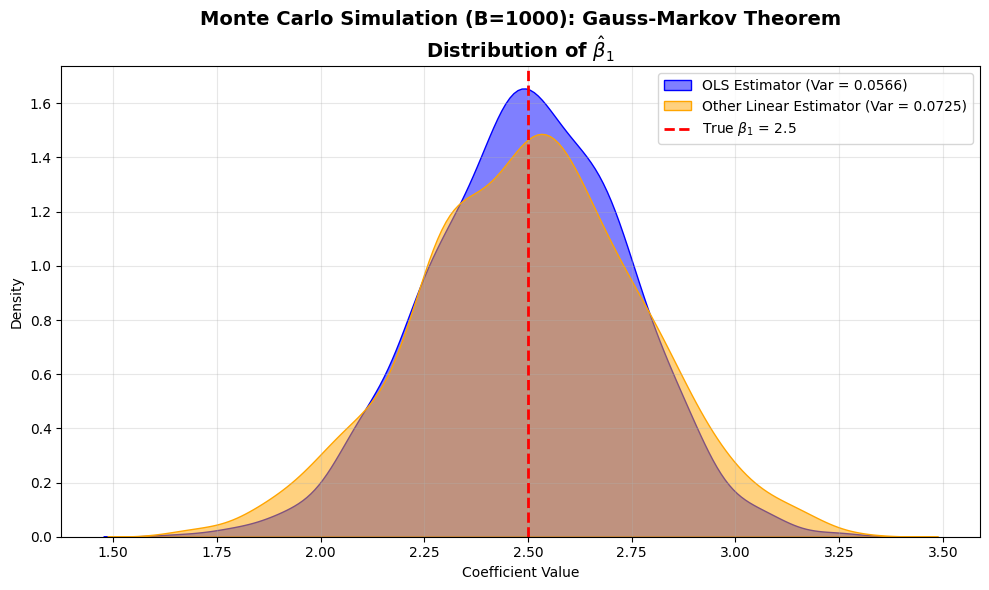

In [38]:
# VẼ BIỂU ĐỒ SO SÁNH (Ví dụ vẽ cho hệ số beta_1)
coef_idx = 1  # Chọn hệ số beta_1 (giá trị thực là 2.5)

plt.figure(figsize=(10, 6))
sns.kdeplot(
    beta_ols_results[:, coef_idx], 
    fill=True, 
    color="blue", 
    alpha=0.5,
    label=f"OLS Estimator (Var = {beta_ols_results[:, coef_idx].var():.4f})"
)
sns.kdeplot(
    beta_other_results[:, coef_idx], 
    fill=True, 
    color="orange", 
    alpha=0.5,
    label=f"Other Linear Estimator (Var = {beta_other_results[:, coef_idx].var():.4f})"
)

# Vẽ đường thẳng chỉ giá trị thực
plt.axvline(
    beta_true[coef_idx], 
    color="red", 
    linestyle="--", 
    linewidth=2, 
    label=f"True $\\beta_{coef_idx}$ = {beta_true[coef_idx]}"
)

plt.title(f"Monte Carlo Simulation (B={B}): Gauss-Markov Theorem\nDistribution of $\\hat{{\\beta}}_{coef_idx}$", fontsize=14, fontweight="bold")
plt.xlabel("Coefficient Value")
plt.ylabel("Density")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()